# Session 2. Transformer

## 목표
**GPT 논문을 읽을 수 있다.**

이번 세션의 목표는 Transformer 구조를 “외워서 설명”하는 것이 아니라,  
GPT 계열 논문을 읽을 때 반복적으로 등장하는 핵심 개념을 이해하는 것입니다.

다루는 흐름은 다음과 같습니다.

1. 왜 RNN 기반 구조가 한계에 부딪혔는가
2. Attention은 무엇을 해결했는가
3. Query / Key / Value는 어떤 의미인가
4. Multi-Head Attention은 왜 필요한가
5. Positional Encoding은 왜 필요한가
6. Transformer Block은 어떻게 구성되는가
7. KV Cache는 왜 LLM inference의 핵심인가

**참고자료**

- CS231n RNN Tutorial (https://cs231n.github.io/rnn/)
- Visualizing Seq2Seq Models (Jay Alammar) (https://jalammar.github.io/visualizing-neural-machine-translation-mechanics-of-seq2seq-models-with-attention/)
- Understanding LSTM Networks (Colah) (https://colah.github.io/posts/2015-08-Understanding-LSTMs/)
- Illinois Attention Lecture Slides (chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/https://slazebni.cs.illinois.edu/spring24/lec18_attention.pdf)
- Attention Is All You Need (https://arxiv.org/abs/1706.03762)
- RoFormer (https://arxiv.org/abs/2104.09864)

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import sklearn
import torch

print("numpy:", np.__version__)
print("sklearn:", sklearn.__version__)
print("torch:", torch.__version__)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

numpy: 2.4.6
sklearn: 1.9.0
torch: 2.12.0+cpu
device: cpu


---

# 1. Why RNN Failed

Transformer가 등장하기 전, 자연어 처리는 RNN, LSTM, GRU 같은 **순차 모델(sequence model)** 이 중심이었습니다.

RNN은 입력과 출력의 개수에 따라 여러 형태로 활용될 수 있습니다.  
예를 들어 하나의 입력에서 하나의 출력을 내는 분류 문제, 하나의 입력에서 여러 출력을 생성하는 이미지 캡셔닝, 여러 입력을 읽고 하나의 출력을 내는 감성분석, 여러 입력을 받아 여러 출력을 생성하는 기계번역 등이 있습니다.

<center>
<img src="./images/types_of_rnn_architecture.png" width="700">
<br>
<em>Figure 1. Different types of RNN architectures. Red boxes are input vectors, green boxes are hidden states, and blue boxes are output vectors.</em>
</center>



하지만 자연어 처리에서 핵심이 되는 구조는 결국 **sequence를 왼쪽에서 오른쪽으로 하나씩 읽는 방식**입니다.

RNN은 현재 입력 $x_t$ 와 이전 hidden state $h_{t-1}$ 를 사용하여 현재 hidden state $h_t$ 를 계산합니다.

$$
h_t = f(x_t, h_{t-1})
$$

즉, 하나의 RNN Cell이 시간(Time) 축을 따라 반복적으로 사용됩니다. 이를 펼쳐서(Unroll) 표현하면 아래와 같습니다.

<center>
<img src="./images/simpleRNN_unrolledRNN.png" width="700">
<br>
<em>Figure 2. Unrolled RNN. The same recurrent cell is repeatedly applied across time steps while passing hidden states from left to right.</em> 
</center>

이 구조는 매우 직관적입니다. 문장을 앞에서부터 차례대로 읽으면서 지금까지의 정보를 hidden state에 저장하고, 다음 단어를 처리할 때 활용합니다.

예를 들어 다음 문장을 처리한다고 가정해보겠습니다.

"The patient was discharged yesterday."

RNN은 아래와 같이 단어를 하나씩 순차적으로 읽습니다.

"The → patient → was → discharged → yesterday"

각 시점에서 생성된 hidden state는 다음 시점으로 전달되며, 모델은 이를 통해 문맥(Context)을 유지하려고 합니다.

하지만 RNN에는 두 가지 근본적인 한계가 있습니다.


## 1.1 Long Dependency

문장이 길어질수록 앞쪽 정보가 뒤쪽까지 잘 전달되지 않습니다.

예를 들어:

> The **patient** who had been admitted to the ICU after severe pneumonia and multiple complications **was discharged**.

`patient`와 `was discharged`는 의미적으로 연결되어 있지만, 두 단어 사이에는 많은 정보가 끼어 있습니다.

RNN은 이런 장거리 의존성을 hidden state 하나에 압축해서 전달해야 합니다.

결과적으로 긴 문장에서는 중요한 정보가 희석되기 쉽습니다.



Long Dependency 문제를 완화하기 위해 **LSTM (Long Short-Term Memory)** 과 **GRU (Gated Recurrent Unit)** 가 제안되었습니다.


기존 RNN은 하나의 hidden state만 다음 시점으로 전달합니다.

LSTM은 기존 RNN보다 복잡한 내부 구조를 가지고 있으며, 정보를 선택적으로 기억하고 삭제할 수 있는 Gate를 도입하였습니다.

LSTM의 핵심은 두 가지 상태(State)를 유지한다는 점입니다.

- **Cell State ($C_t$)** : 장기 기억 (Long-Term Memory)
- **Hidden State ($h_t$)** : 단기 기억 (Short-Term Memory)

LSTM은 단순히 hidden state만 전달하던 기존 RNN과 달리, 중요한 정보를 오랫동안 보존할 수 있는 **Memory Cell** 구조를 추가하였습니다.

<center>
<table>
<tr>
<td align="center">
<img src="./images/rnn_cell.png" width="550">
</td>
<td align="center">
<img src="./images/lstm_cell.png" width="550">
</td>
</tr>
<tr>
<td align="center">
<em>(a) Standard RNN Cell </em>
</td>
<td align="center">
<em>(b) LSTM Cell</em>
</td>
</tr>
</table>

<br>

<em>Figure 3. RNN & LSTM CELL.</em>

</center>

예를 들어,

> The patient who had been admitted to the ICU after severe pneumonia and multiple complications was discharged.

문장을 처리할 때 `patient`에 대한 중요한 정보는 Cell State를 통해 오랫동안 유지하고, 현재 단어를 처리하기 위해 필요한 정보는 Hidden State를 통해 전달합니다.

이 덕분에 LSTM은 기존 RNN보다 훨씬 긴 문장의 문맥을 기억할 수 있게 되었습니다.

하지만 LSTM과 GRU 역시 근본적으로는 순차 모델입니다.


## 1.2 Sequential Bottleneck

RNN은 이전 시점의 계산이 끝나야 다음 시점을 계산할 수 있습니다.

```text
h1 계산 → h2 계산 → h3 계산 → h4 계산
```

즉, 병렬화가 어렵습니다.

GPU는 병렬 계산에 강한데, RNN 구조는 이 장점을 충분히 활용하지 못합니다.

Transformer는 이 문제를 Attention으로 해결합니다.

# 2. Attention

LSTM은 Long Dependency 문제를 상당 부분 개선하였지만, Seq2Seq 구조에는 여전히 한계가 존재했습니다.

기존 Seq2Seq 모델은 입력 문장 전체를 하나의 Context Vector에 압축하여 Decoder에 전달했습니다.

문장이 짧을 때는 큰 문제가 없었지만, 문장이 길어질수록 중요한 정보가 하나의 벡터에 압축되면서 정보 손실이 발생하였습니다.

이를 해결하기 위해 연구자들은 다음과 같은 질문을 던졌습니다.

> Decoder가 출력 단어를 생성할 때, 입력 문장 전체를 다시 참고할 수는 없을까?

이 아이디어에서 등장한 것이 **Attention Mechanism** 입니다.

---

## 2.1 RNN + Attention

2015년 Bahdanau 등이 발표한 논문 *Neural Machine Translation by Jointly Learning to Align and Translate* 에서는 Seq2Seq 모델에 Attention을 추가하였습니다.

<center>
<table>
<tr>
<td align="center">
<img src="./images/seq2seq_modeling_with_rnn.png" width="550">
</td>
<td align="center">
<img src="./images/seq2seq_attention.png" width="550">
</td>
</tr>
<tr>
<td align="center">
<em>(a) Seq2Seq using RNN</em>
</td>
<td align="center">
<em>(b) Seq2Seq with Attention</em>
</td>
</tr>
</table>

<br>

<em>Figure 5. Comparison between traditional Seq2Seq and Seq2Seq with Attention. Attention allows the decoder to directly access relevant encoder hidden states instead of relying on a single context vector.</em>

</center>

Attention은 Decoder가 출력 단어를 생성할 때 입력 문장의 모든 hidden state를 살펴보고, 현재 단어와 가장 관련 있는 단어에 높은 가중치를 부여합니다.

예를 들어 번역 모델이 "estamos"를 생성할 때,

```text
we are eating bread
```

전체 문장을 다시 참고하면서 특히 `we`, `are`에 더 집중할 수 있습니다.

이러한 가중치를 **Attention Score** 라고 합니다.

즉, Attention은 다음 질문에 답하는 메커니즘입니다.

> 현재 단어를 이해하기 위해 어떤 단어를 얼마나 참고해야 하는가?

RNN + Attention은 기존 Seq2Seq보다 훨씬 좋은 성능을 보였지만, 여전히 Encoder와 Decoder가 RNN 기반이었기 때문에 순차 계산 문제는 남아 있었습니다.

이후 2017년 발표된 **Attention Is All You Need** 논문에서는 RNN을 완전히 제거하고, Attention만으로 구성된 새로운 구조인 **Transformer** 를 제안하게 됩니다.

## 2.2 Attention Is All You Need

RNN + Attention은 기존 Seq2Seq보다 훨씬 좋은 성능을 보였지만, 여전히 Encoder와 Decoder가 RNN 기반이었기 때문에 순차 계산 문제가 남아 있었습니다.

연구자들은 다음과 같은 질문을 던졌습니다.

> RNN을 완전히 제거하고 Attention만으로 Sequence Modeling을 할 수는 없을까?

이 질문에 대한 답이 바로 2017년 Google이 발표한 논문

**"Attention Is All You Need"**

입니다.

이 논문은 RNN과 CNN을 모두 제거하고, Attention만으로 구성된 새로운 구조인 Transformer를 제안하였습니다.

<center>
<img src="./images/transformer_arch.png" width="300">
<br>
<em>Figure 6. Transformer architecture proposed in "Attention Is All You Need" (Vaswani et al., 2017).</em>
</center>

Transformer의 핵심 아이디어는 매우 단순합니다.

> 문장을 순차적으로 읽지 말고,
> 모든 단어가 서로를 직접 참고하도록 만들자.


---

# 3. Query, Key, Value

Attention은 Query, Key, Value로 구성됩니다.

각 token은 세 가지 벡터로 변환됩니다.

| 구성요소 | 직관적 의미 |
|---|---|
| Query | 내가 찾고 싶은 정보 |
| Key | 내가 가진 정보의 이름표 |
| Value | 실제 전달할 정보 |

비유하면 다음과 같습니다.

- Query: “나는 어떤 정보를 찾고 있나?”
- Key: “나는 어떤 종류의 정보인가?”
- Value: “내가 실제로 줄 정보는 무엇인가?”

Attention score는 Query와 Key의 유사도로 계산됩니다.

Query와 Key가 잘 맞으면 해당 token의 Value를 많이 가져옵니다.

설명: https://wikidocs.net/31379

## 3.1 Scaled Dot-Product Attention

Transformer에서 사용하는 attention은 다음과 같습니다.

\[
Attention(Q, K, V) = softmax \left( \frac{QK^T}{\sqrt{d_k}} \right) V
\]

의미는 다음 순서입니다.

1. Query와 Key의 유사도를 계산한다.
2. 너무 값이 커지지 않도록 \(\sqrt{d_k}\)로 나눈다.
3. softmax로 attention weight를 만든다.
4. attention weight를 Value에 곱해 필요한 정보를 섞는다.

In [11]:
# Scaled Dot-Product Attention을 직접 구현해봅니다.

import torch
import torch.nn.functional as F

torch.manual_seed(42)

# 예시: token 4개, embedding dimension 8
seq_len = 4
d_model = 8
d_k = 8

X = torch.randn(seq_len, d_model)

# 실제 Transformer에서는 W_Q, W_K, W_V가 학습됩니다.
W_Q = torch.randn(d_model, d_k)
W_K = torch.randn(d_model, d_k)
W_V = torch.randn(d_model, d_k)

Q = X @ W_Q
K = X @ W_K
V = X @ W_V

scores = Q @ K.T / (d_k ** 0.5)
attention_weights = F.softmax(scores, dim=-1)
output = attention_weights @ V

print("Input shape:", X.shape)
print("Q shape:", Q.shape)
print("K shape:", K.shape)
print("V shape:", V.shape)
print("Attention weights shape:", attention_weights.shape)
print("Output shape:", output.shape)

print("\nAttention weights:")
print(attention_weights)

Input shape: torch.Size([4, 8])
Q shape: torch.Size([4, 8])
K shape: torch.Size([4, 8])
V shape: torch.Size([4, 8])
Attention weights shape: torch.Size([4, 4])
Output shape: torch.Size([4, 8])

Attention weights:
tensor([[9.9999e-01, 2.2638e-08, 4.5571e-07, 1.1432e-05],
        [1.1078e-02, 9.8871e-01, 1.2271e-04, 8.5189e-05],
        [1.5654e-06, 6.1913e-04, 9.7855e-01, 2.0830e-02],
        [3.0778e-07, 8.7853e-08, 9.9291e-01, 7.0907e-03]])


위 결과에서 `attention_weights`는 각 token이 다른 token을 얼마나 참고하는지 보여줍니다.

shape이 `(4, 4)`인 이유는 token 4개가 각각 token 4개를 바라보기 때문입니다.

```text
token 1 → token 1,2,3,4
token 2 → token 1,2,3,4
token 3 → token 1,2,3,4
token 4 → token 1,2,3,4
```

---
## 3.2 Self-attention vs Cross-attention
지금까지 우리는 Attention이라는 개념을 살펴보았습니다.

그렇다면 Transformer에서 자주 등장하는 **Self-Attention** 은 일반적인 Attention과 무엇이 다를까요?

핵심 차이는 Query, Key, Value가 어디에서 생성되는가에 있습니다.

### Attention (Cross-Attention)

일반적인 Attention에서는 Query와 Key/Value가 서로 다른 입력에서 생성될 수 있습니다.

예를 들어 기계번역 모델에서는
```text
Encoder Output
      ↓
    Key, Value

Decoder Hidden State
      ↓
     Query
```
Decoder는 Encoder의 출력 중 어떤 부분을 참고해야 하는지 Attention Score를 계산합니다.

이를 **Cross-Attention** 이라고 부릅니다.

---

### Self-Attention

반면 Transformer의 핵심인 Self-Attention에서는 Query, Key, Value가 모두 같은 입력으로부터 생성됩니다.

```text
Input Tokens
      ↓
Q, K, V 생성
      ↓
Self-Attention
```
즉,

- Query : 입력 토큰
- Key : 입력 토큰
- Value : 입력 토큰

모두 동일한 입력에서 생성됩니다.

그래서 Self-Attention이라는 이름이 붙었습니다.
즉, Self-Attention은

> "현재 토큰이 문장 안의 다른 토큰들을 얼마나 참고해야 하는가?"

를 학습하는 과정이라고 볼 수 있습니다.



---

## 3.3. Multi-Head Attention

하나의 attention만 쓰면 한 가지 관점으로만 token 관계를 봅니다.

하지만 문장에는 여러 종류의 관계가 있습니다.

- 문법적 관계
- 의미적 관계
- 주어-동사 관계
- 앞뒤 문맥 관계
- 지시어 관계

Multi-Head Attention은 attention을 여러 개의 head로 나누어,  
각 head가 서로 다른 관계를 학습하게 합니다.

```text
Head 1: 문법 관계
Head 2: 의미 관계
Head 3: 지시어 관계
Head 4: 위치 관계
```

실제로 각 head가 반드시 사람이 해석 가능한 역할로 나뉘는 것은 아니지만,  
여러 표현 공간에서 attention을 수행한다는 것이 핵심입니다.

In [12]:
# PyTorch의 MultiheadAttention을 사용해봅니다.

import torch
import torch.nn as nn

torch.manual_seed(42)

seq_len = 5
batch_size = 2
d_model = 16
num_heads = 4

x = torch.randn(seq_len, batch_size, d_model)

mha = nn.MultiheadAttention(embed_dim=d_model, num_heads=num_heads, batch_first=False)

attn_output, attn_weights = mha(x, x, x)

print("Input shape:", x.shape)
print("Output shape:", attn_output.shape)
print("Attention weights shape:", attn_weights.shape)

Input shape: torch.Size([5, 2, 16])
Output shape: torch.Size([5, 2, 16])
Attention weights shape: torch.Size([2, 5, 5])


`x, x, x`를 넣은 이유는 Self-Attention이기 때문입니다.

Self-Attention에서는 같은 입력에서 Query, Key, Value를 모두 만듭니다.

```python
mha(x, x, x)
```

즉, 문장 안의 token들이 자기들끼리 서로를 참고합니다.

---

# 4. Positional Encoding

Attention은 모든 token을 한 번에 비교합니다.

이 구조는 병렬화에는 좋지만, 한 가지 문제가 있습니다.

> Attention 자체는 token의 순서를 모릅니다.

예를 들어 다음 두 문장은 단어는 같지만 의미가 다릅니다.

```text
dog bites man
man bites dog
```

Attention만 쓰면 token 집합은 같기 때문에 순서 정보를 따로 넣어줘야 합니다.

이때 사용하는 것이 Positional Encoding입니다.

## 4.1 Sinusoidal Positional Encoding

*Attention Is All You Need* 논문에서는 sin, cos 함수를 사용한 Positional Encoding을 제안했습니다.

Positional Encoding은 각 위치(Position)에 대해 고유한 벡터를 생성하여, Transformer가 토큰의 순서 정보를 학습할 수 있도록 합니다.

짝수 차원(Even Dimension)은 sine 함수를 사용합니다.

$$
PE(pos, 2i)
=
\sin \left(
\frac{pos}
{10000^{\frac{2i}{d_{model}}}}
\right)
$$

홀수 차원(Odd Dimension)은 cosine 함수를 사용합니다.

$$
PE(pos, 2i+1)
=
\cos \left(
\frac{pos}
{10000^{\frac{2i}{d_{model}}}}
\right)
$$

여기서

- $pos$ : 토큰 위치 (position)
- $i$ : embedding dimension index
- $d_{model}$ : embedding dimension 크기

를 의미합니다.

Sinusoidal Positional Encoding의 특징은 다음과 같습니다.

- 위치마다 고유한 벡터를 생성한다.
- 학습 파라미터 없이 계산 가능하다.
- 서로 다른 주파수(Frequency)를 사용하여 위치 정보를 표현한다.
- 상대적 위치 관계를 자연스럽게 표현할 수 있다.

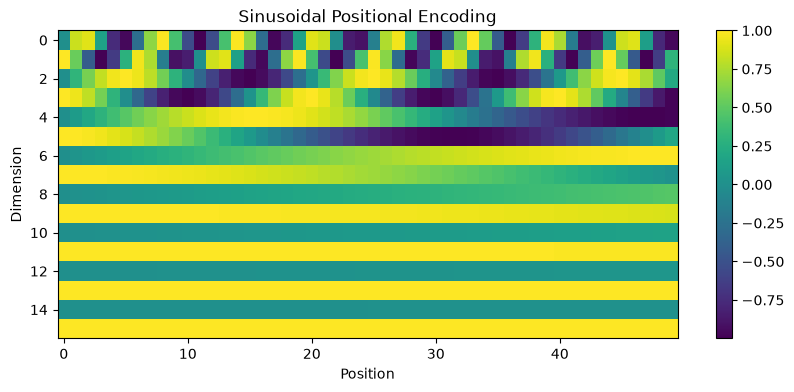

In [13]:
# Sinusoidal Positional Encoding 시각화

import math
import torch
import matplotlib.pyplot as plt

def sinusoidal_positional_encoding(max_len, d_model):
    pe = torch.zeros(max_len, d_model)
    position = torch.arange(0, max_len).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))

    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe

max_len = 50
d_model = 16

pe = sinusoidal_positional_encoding(max_len, d_model)

plt.figure(figsize=(10, 4))
plt.imshow(pe.T, aspect="auto")
plt.xlabel("Position")
plt.ylabel("Dimension")
plt.title("Sinusoidal Positional Encoding")
plt.colorbar()
plt.show()

위 그림에서 x축은 token 위치, y축은 embedding dimension입니다.

Dimension 0~3 : 빠르게 반복되는 sin/cos
Dimension 4~8 : 완만한 파동
Dimension 10 이후 : 거의 직선처럼 보임


각 위치는 서로 다른 패턴의 벡터를 갖습니다.  
Transformer는 token embedding에 positional encoding을 더해서 순서 정보를 함께 사용합니다.

## 4.2 RoPE: Rotary Positional Embedding

RoPE(Rotary Positional Embedding)는 *RoFormer* 논문에서 제안된 Positional Encoding 방식입니다.

기존 Sinusoidal Positional Encoding이 위치 정보를 Embedding에 더했다면, RoPE는 Query와 Key 벡터를 위치에 따라 회전시켜 위치 정보를 Attention 계산에 직접 반영합니다.

<center>
<img src="./images/rope_example.png" width="700">
<br>
<em>Figure 11. Query와 Key 벡터는 위치에 따라 서로 다른 각도로 회전한다.</em>
</center>

즉, 동일한 토큰이라도 위치에 따라 서로 다른 표현을 갖게 되며, 모델은 토큰 간 상대적인 위치 관계를 자연스럽게 학습할 수 있습니다.

<center>
<img src="./images/ROPE_attention.png" width="600">
<br>
<em>Figure 12. RoPE는 회전된 Query와 Key를 사용하여 Attention Score를 계산한다.</em>
</center>

RoPE는 긴 문맥(Long Context)에 강하고 상대 위치 정보를 효과적으로 표현할 수 있어, 현재 대부분의 LLM(LLaMA, Qwen, DeepSeek 등)에서 사용되고 있습니다.

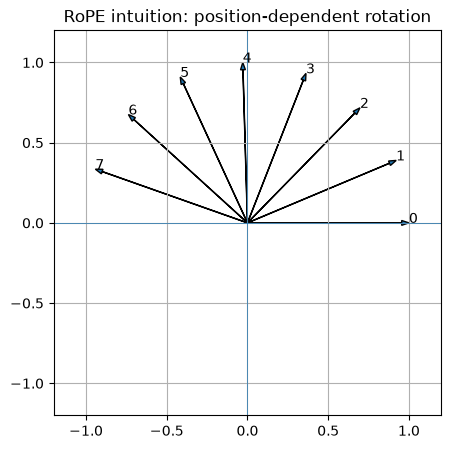

In [14]:
# RoPE의 핵심 직관: 2차원 벡터를 위치에 따라 회전시키기

import torch
import math
import matplotlib.pyplot as plt

def rotate_vector(v, theta):
    rotation = torch.tensor([
        [math.cos(theta), -math.sin(theta)],
        [math.sin(theta),  math.cos(theta)]
    ], dtype=torch.float32)
    return rotation @ v

v = torch.tensor([1.0, 0.0])

positions = list(range(8))
rotated = torch.stack([rotate_vector(v, pos * 0.4) for pos in positions])

plt.figure(figsize=(5, 5))
for i, vec in enumerate(rotated):
    plt.arrow(0, 0, vec[0].item(), vec[1].item(), head_width=0.03, length_includes_head=True)
    plt.text(vec[0].item(), vec[1].item(), str(i))

plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.axhline(0, linewidth=0.5)
plt.axvline(0, linewidth=0.5)
plt.title("RoPE intuition: position-dependent rotation")
plt.grid(True)
plt.show()

---

# 5. Transformer Block

Transformer는 attention 하나만으로 구성되지 않습니다.

기본 block은 다음 요소들로 이루어집니다.

```text
Input
  ↓
Self-Attention
  ↓
Residual Connection
  ↓
LayerNorm
  ↓
Feed Forward Network
  ↓
Residual Connection
  ↓
LayerNorm
  ↓
Output
```

GPT 계열 모델은 decoder-only Transformer입니다.

즉, 다음 token을 예측하기 위해 이전 token들만 볼 수 있도록 causal mask를 사용합니다.

## 5.1 Attention

Attention은 token 간 관계를 학습합니다.

예를 들어 문장 안에서 어떤 단어가 어떤 단어를 참고해야 하는지를 계산합니다.

## 5.2 FFN

FFN은 각 token에 독립적으로 적용되는 작은 MLP입니다.

Attention이 token 사이의 관계를 섞는 역할이라면,  
FFN은 각 token의 표현을 더 복잡하게 변환하는 역할입니다.

## 5.3 Residual Connection

Residual connection은 입력을 출력에 더합니다.

\[
y = x + F(x)
\]

이 구조는 깊은 모델의 학습을 안정화합니다.

## 5.4 LayerNorm

LayerNorm은 각 token의 hidden dimension을 정규화합니다.

큰 모델에서는 activation scale이 불안정해지기 쉬운데,  
LayerNorm은 학습을 안정화하는 역할을 합니다.

In [15]:
# 아주 작은 Transformer Block 구현

import torch
import torch.nn as nn

class TinyTransformerBlock(nn.Module):
    def __init__(self, d_model=32, num_heads=4, d_ff=128):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, num_heads, batch_first=True)
        self.ln1 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model)
        )
        self.ln2 = nn.LayerNorm(d_model)

    def forward(self, x, attn_mask=None):
        attn_out, _ = self.attn(x, x, x, attn_mask=attn_mask)
        x = self.ln1(x + attn_out)

        ffn_out = self.ffn(x)
        x = self.ln2(x + ffn_out)
        return x

batch_size = 2
seq_len = 6
d_model = 32

x = torch.randn(batch_size, seq_len, d_model)

block = TinyTransformerBlock(d_model=d_model, num_heads=4)
out = block(x)

print("Input shape:", x.shape)
print("Output shape:", out.shape)

Input shape: torch.Size([2, 6, 32])
Output shape: torch.Size([2, 6, 32])


---

## 5.5 Causal Mask

GPT는 다음 token을 예측하는 모델입니다.

따라서 현재 token이 미래 token을 보면 안 됩니다.

예를 들어:

```text
I love deep learning
```

`love`를 처리할 때 `deep`, `learning`을 미리 보면 정답을 훔쳐보는 것이 됩니다.

그래서 GPT는 causal mask를 사용합니다.

```text
token 1 → token 1만 볼 수 있음
token 2 → token 1,2만 볼 수 있음
token 3 → token 1,2,3만 볼 수 있음
```

tensor([[False,  True,  True,  True,  True,  True,  True,  True],
        [False, False,  True,  True,  True,  True,  True,  True],
        [False, False, False,  True,  True,  True,  True,  True],
        [False, False, False, False,  True,  True,  True,  True],
        [False, False, False, False, False,  True,  True,  True],
        [False, False, False, False, False, False,  True,  True],
        [False, False, False, False, False, False, False,  True],
        [False, False, False, False, False, False, False, False]])


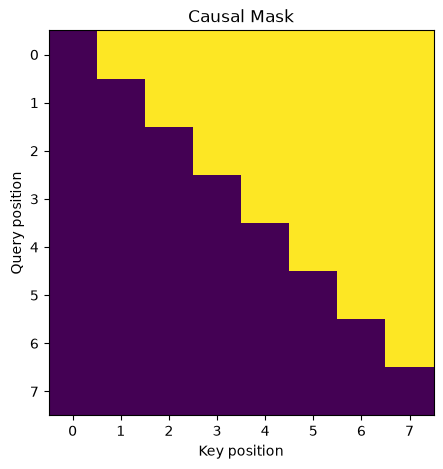

In [16]:
# Causal mask 만들기

import torch
import matplotlib.pyplot as plt

seq_len = 8

# True인 위치는 attention을 막을 위치입니다.
causal_mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()

print(causal_mask)

plt.figure(figsize=(5, 5))
plt.imshow(causal_mask)
plt.title("Causal Mask")
plt.xlabel("Key position")
plt.ylabel("Query position")
plt.show()

---

# 6. KV Cache

LLM inference에서 KV Cache는 매우 중요합니다.

Transformer는 새 token을 생성할 때마다 attention을 계산합니다.

문제는 autoregressive generation에서는 token을 하나씩 생성한다는 점입니다.

```text
입력 prompt → 다음 token 생성 → 그 다음 token 생성 → ...
```

매번 전체 prompt에 대해 Key, Value를 다시 계산하면 매우 비효율적입니다.

KV Cache는 이전 token들의 Key, Value를 저장해두고 재사용하는 기법입니다.

## 6.1 왜 필요한가

예를 들어 prompt 길이가 1,000 token이고, 새 token을 100개 생성한다고 합시다.

KV Cache가 없다면 매 step마다 기존 1,000개 이상의 token에 대해 Key/Value를 다시 계산해야 합니다.

KV Cache가 있으면 이전 token의 Key/Value는 저장해두고,  
새로 들어온 token의 Key/Value만 계산하면 됩니다.

이 덕분에 decode 단계가 훨씬 빨라집니다.

## 6.2 Prefill과 Decode

LLM 추론(Inference)은 크게 **Prefill** 과 **Decode** 두 단계로 나뉩니다.

<center>
<img src="./images/prefill_decode.png" width="750">
<br>
<em>Figure 16. During Prefill, Key/Value tensors are computed and stored in KV Cache. During Decode, previously cached Key/Value tensors are reused.</em>
</center>

### (1) Prefill

사용자가 입력한 prompt 전체를 한 번에 처리합니다.
Prefill은 병렬화가 잘 됩니다.  
하지만 prompt가 길수록 메모리와 계산량이 커집니다.

### (2) Decode

이후 token을 하나씩 생성합니다.

```text
새 token 1개 입력
→ cache된 K/V와 attention
→ 다음 token 생성
```

Decode는 token을 하나씩 생성하므로 순차적입니다.  
LLM serving에서 latency가 중요한 이유가 여기에 있습니다.

In [17]:
# KV Cache의 shape 직관

batch_size = 1
num_heads = 4
seq_len = 10
head_dim = 8

# 한 layer에서 저장되는 Key/Value cache
key_cache = torch.randn(batch_size, num_heads, seq_len, head_dim)
value_cache = torch.randn(batch_size, num_heads, seq_len, head_dim)

print("Key cache shape:", key_cache.shape)
print("Value cache shape:", value_cache.shape)

# 새 token이 하나 생성되면 seq_len 방향으로 cache가 늘어납니다.
new_key = torch.randn(batch_size, num_heads, 1, head_dim)
new_value = torch.randn(batch_size, num_heads, 1, head_dim)

key_cache = torch.cat([key_cache, new_key], dim=2)
value_cache = torch.cat([value_cache, new_value], dim=2)

print("Updated key cache shape:", key_cache.shape)
print("Updated value cache shape:", value_cache.shape)

Key cache shape: torch.Size([1, 4, 10, 8])
Value cache shape: torch.Size([1, 4, 10, 8])
Updated key cache shape: torch.Size([1, 4, 11, 8])
Updated value cache shape: torch.Size([1, 4, 11, 8])


## 6.3 Continuous Batching

LLM Serving에서는 여러 사용자의 요청을 동시에 처리해야 합니다.

기존 Static Batching은 하나의 요청이 먼저 종료되더라도 Batch가 끝날 때까지 빈 공간이 발생합니다.

<center>
<img src="./images/continous_batching.png" width="800">
<br>
<em>Figure 17. Static Batching vs Continuous Batching. Continuous Batching improves GPU utilization by immediately filling available slots with new requests.</em>
</center>

Continuous Batching은 요청이 종료되는 즉시 새로운 요청을 Batch에 추가합니다.

이를 통해 GPU 활용률을 높이고, 더 많은 요청을 효율적으로 처리할 수 있습니다.

vLLM, TensorRT-LLM, SGLang 등 최신 LLM Serving Framework의 핵심 최적화 기법 중 하나입니다.

---

# 7. GPT 논문을 읽을 때 보는 포인트

GPT 계열 논문을 읽을 때는 다음 질문을 가지고 보면 좋습니다.

## 7.1 모델 구조

- Decoder-only Transformer인가?
- Attention 구조는 어떤 변형을 쓰는가?
- Positional Encoding은 무엇을 쓰는가?
- LayerNorm 위치는 Pre-LN인가, Post-LN인가?
- FFN activation은 무엇인가?
- context length는 얼마인가?

## 7.2 학습 방식

- next token prediction인가?
- instruction tuning을 했는가?
- RLHF 또는 preference optimization을 썼는가?
- 데이터 규모와 품질은 어떻게 설명되는가?

## 7.3 Inference 최적화

- KV Cache를 사용하는가?
- 긴 context를 어떻게 처리하는가?
- serving latency나 throughput을 어떻게 개선하는가?

---

# 오늘의 핵심 요약

1. RNN은 long dependency와 sequential bottleneck 때문에 대규모 병렬 학습에 불리했습니다.
2. Attention은 모든 token이 서로를 직접 참고하게 만듭니다.
3. Query는 찾는 정보, Key는 매칭 기준, Value는 실제 전달 정보입니다.
4. Multi-Head Attention은 여러 관점에서 token 관계를 학습합니다.
5. Positional Encoding은 attention에 순서 정보를 제공합니다.
6. Transformer Block은 Attention, FFN, Residual, LayerNorm으로 구성됩니다.
7. GPT는 미래 token을 보지 않기 위해 causal mask를 사용합니다.
8. KV Cache는 LLM inference에서 decode 속도를 높이는 핵심 기술입니다.
9. Prefill은 prompt 전체 처리, Decode는 token-by-token 생성입니다.
10. GPT 논문을 읽을 때는 구조, 학습 방식, inference 최적화를 구분해서 보면 됩니다.